# Analisis de Incidencia Delictiva en México

**Objetivo**
El objetivo de este proyecto es analizar datos de la incidencia delictiva para identificar patrones, tendencias y zonas de mayor riesgo, utilizando herramientas de análisis de datos en Python.

**Contexto**
Este análisis busca apoyar la toma de decisiones mediante el uso de datos, permieiendo detectar comportamientos relevantes en la incidencia delictiva.

**Herramientas utilizadas**
-Python
-Pandas
-Matplotib/Seaborn

In [2]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta_fuentes ="/content/drive/MyDrive/PROYECTO DELINCUENCIA"

In [5]:
df_delitos = pd.read_csv(f'{ruta_fuentes}/IDEFC_NM_ago25.csv', encoding='latin1')
df_victimas = pd.read_csv(f'{ruta_fuentes}/IDVFC_NM_ago25.csv', encoding='latin1')
df_delitos_municipal = pd.read_csv(f'{ruta_fuentes}/Municipal-Delitos-2015-2025_ago2025.csv', encoding='latin1')

In [6]:
display(df_delitos)

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,3,0,2,1,1,1,2,1,2,2,2,1
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,0,0,0,1,0,1,0,0,0,1
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,2,2,3,2,0,1,2,0,0,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,2,0,0,1,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31355,2024,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Falsificación,Falsificación,Falsificación,3,9,16,14,8,8,8,10,11,19,9,5
31356,2024,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Contra el medio ambiente,Contra el medio ambiente,Contra el medio ambiente,0,0,0,0,0,0,2,0,0,0,0,1
31357,2024,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,21,22,33,35,36,37,28,24,21,26,27,27
31358,2024,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Electorales,Electorales,Electorales,0,1,0,10,31,22,0,0,0,0,0,0


In [7]:
df_delitos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31360 entries, 0 to 31359
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Año                     31360 non-null  int64 
 1   Clave_Ent               31360 non-null  int64 
 2   Entidad                 31360 non-null  object
 3   Bien jurídico afectado  31360 non-null  object
 4   Tipo de delito          31360 non-null  object
 5   Subtipo de delito       31360 non-null  object
 6   Modalidad               31360 non-null  object
 7   Enero                   31360 non-null  int64 
 8   Febrero                 31360 non-null  int64 
 9   Marzo                   31360 non-null  int64 
 10  Abril                   31360 non-null  int64 
 11  Mayo                    31360 non-null  int64 
 12  Junio                   31360 non-null  int64 
 13  Julio                   31360 non-null  int64 
 14  Agosto                  31360 non-null  int64 
 15  Se

In [8]:
display(df_victimas)
df_victimas['Rango de edad'].unique()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),0,...,0,0,1,0,0,1,0.0,0.0,0.0,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80955,2025,32,Zacatecas,Libertad personal,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,No identificado,No identificado,0,...,0,0,0,0,6,3,NaN,NaN,NaN,NaN
80956,2025,32,Zacatecas,El patrimonio,Extorsión,Extorsión,Extorsión,No identificado,No identificado,0,...,2,1,0,0,0,0,NaN,NaN,NaN,NaN
80957,2025,32,Zacatecas,La sociedad,Corrupción de menores,Corrupción de menores,Corrupción de menores,No identificado,No identificado,1,...,1,0,1,0,1,0,NaN,NaN,NaN,NaN
80958,2025,32,Zacatecas,La sociedad,Trata de personas,Trata de personas,Trata de personas,No identificado,No identificado,0,...,0,0,2,0,0,0,NaN,NaN,NaN,NaN


array(['Menores de edad (0-17)', 'Adultos (18 y más)', 'No especificado',
       'No identificado'], dtype=object)

In [9]:
df_victimas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80960 entries, 0 to 80959
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     80960 non-null  int64  
 1   Clave_Ent               80960 non-null  int64  
 2   Entidad                 80960 non-null  object 
 3   Bien jurídico afectado  80960 non-null  object 
 4   Tipo de delito          80960 non-null  object 
 5   Subtipo de delito       80960 non-null  object 
 6   Modalidad               80960 non-null  object 
 7   Sexo                    80960 non-null  object 
 8   Rango de edad           80960 non-null  object 
 9   Enero                   80960 non-null  int64  
 10  Febrero                 80960 non-null  int64  
 11  Marzo                   80960 non-null  int64  
 12  Abril                   80960 non-null  int64  
 13  Mayo                    80960 non-null  int64  
 14  Junio                   80960 non-null

In [10]:
display(df_delitos_municipal.head())

,Año,Clave_Ent,Entidad,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,...,1,1,0,1,1,0,2.0,1.0,0.0,1.0
1,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,...,0,0,0,1,0,1,0.0,0.0,0.0,0.0
2,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,...,1,1,3,2,0,1,2.0,0.0,0.0,0.0
3,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,1,...,0,1,0,0,0,0,0.0,0.0,0.0,0.0
4,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,...,0,0,1,0,0,0,0.0,0.0,0.0,0.0


In [11]:
# Revisar valores nulos
df_delitos.isnull().sum()

# Eliminar filas con datos faltantes (ejemplo)
df_delitos = df_delitos.dropna()

# Verificar duplicados
df_delitos = df_delitos.drop_duplicates()


# Mandar df a archivo csv para trabajar con df limpio

In [12]:
df_delitos_municipal.to_csv(f'{ruta_fuentes}/Municipal-Delitos-2015-2025.csv', index=False, encoding='latin1')

In [13]:
df_delitos_municipal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2562994 entries, 0 to 2562993
Data columns (total 21 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Año                     int64  
 1   Clave_Ent               int64  
 2   Entidad                 object 
 3   Cve. Municipio          int64  
 4   Municipio               object 
 5   Bien jurídico afectado  object 
 6   Tipo de delito          object 
 7   Subtipo de delito       object 
 8   Modalidad               object 
 9   Enero                   int64  
 10  Febrero                 int64  
 11  Marzo                   int64  
 12  Abril                   int64  
 13  Mayo                    int64  
 14  Junio                   int64  
 15  Julio                   int64  
 16  Agosto                  int64  
 17  Septiembre              float64
 18  Octubre                 float64
 19  Noviembre               float64
 20  Diciembre               float64
dtypes: float64(4), int64(11), objec

In [14]:
top_delitos = df_delitos['Tipo de delito'].value_counts().head(5)
print(top_delitos)

Tipo de delito
Robo           11520
Homicidio       2880
Lesiones        2880
Secuestro       1600
Feminicidio     1280
Name: count, dtype: int64


<Axes: title={'center': 'Top 5 delitos más frecuentes'}, xlabel='Tipo de delito'>

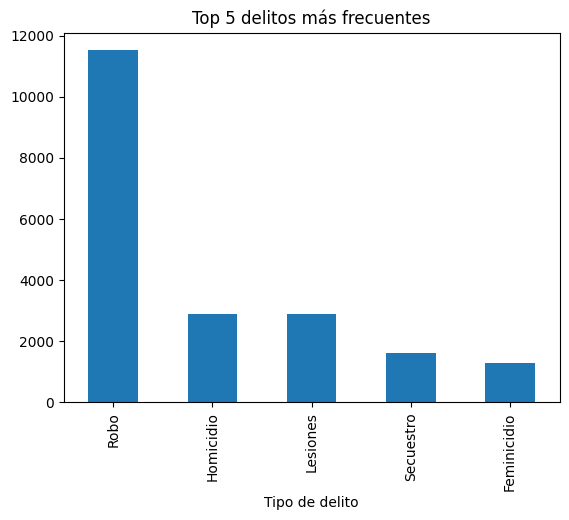

In [15]:
top_delitos.plot(kind='bar', title='Top 5 delitos más frecuentes')

Graficando los resultados observamos que los delitos más frecuentes son robo, seguido de homicidio, lesiones, secuestro y en quinto lugar feminicidio. Lo que nos indica porque el tema de seguridad pública es una de las principales preocupaciones de la población en general.

Haremos una df donde nos muestre el total de delitos cometidos por entidad

In [16]:
# Definir las columnas de los meses para la suma
columnas_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                  'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Calcular la suma de delitos de Enero a Diciembre para cada fila
df_delitos_municipal['Total_Delitos_Anual'] = df_delitos_municipal[columnas_meses].sum(axis=1)

# Agrupar por 'Año' y 'Entidad', y sumar la nueva columna 'Total_Delitos_Anual'.
# El resultado será la suma total de todos los delitos en la entidad para ese año.
df_total_anual_entidad = df_delitos_municipal.groupby(['Año', 'Entidad'])['Total_Delitos_Anual'].sum().reset_index()

# Renombrar la columna de suma para mayor claridad
df_total_anual_entidad.columns = ['Año', 'Entidad', 'Total_Delitos']

display(df_total_anual_entidad)

,Año,Entidad,Total_Delitos
0,2015,Aguascalientes,23212.0
1,2015,Baja California,119944.0
2,2015,Baja California Sur,21415.0
3,2015,Campeche,1886.0
4,2015,Chiapas,21618.0
...,...,...,...
347,2025,Tamaulipas,26936.0
348,2025,Tlaxcala,1753.0
349,2025,Veracruz de Ignacio de la Llave,50702.0
350,2025,Yucatán,3320.0


# Graficar por Estado

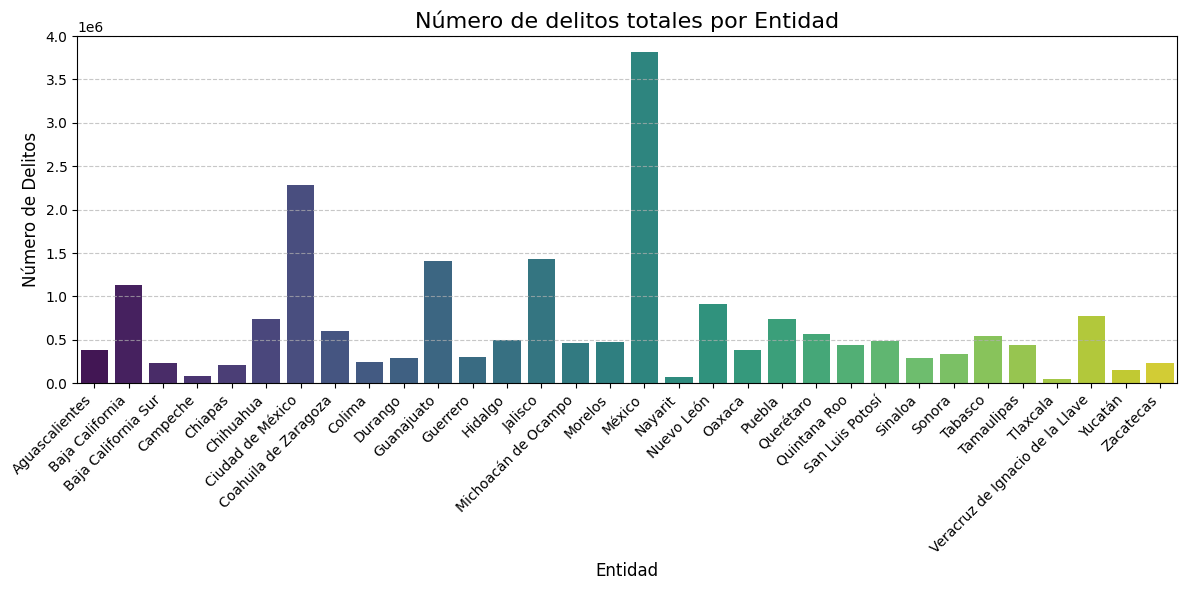

In [17]:
# Agrupar los delitos por Estado
delitos_estado = df_total_anual_entidad.groupby('Entidad')['Total_Delitos'].sum().reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x='Entidad', y='Total_Delitos', data=delitos_estado, palette='viridis', hue='Entidad', legend=False)

# Personalizar el gráfico
plt.title('Número de delitos totales por Entidad', fontsize=16)
plt.xlabel('Entidad', fontsize=12)
plt.ylabel('Número de Delitos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Gráficando por años

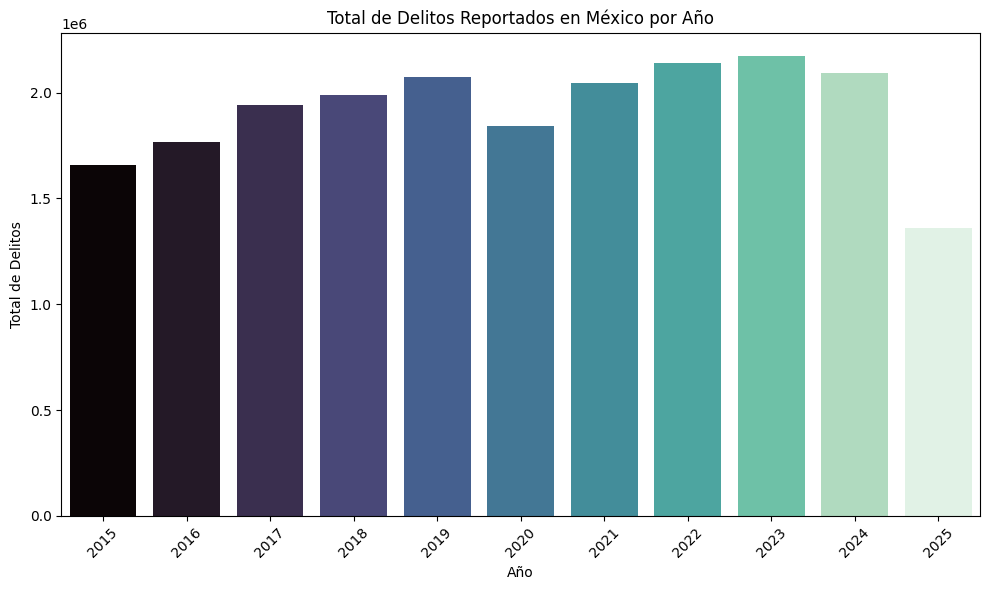

In [18]:
# Agrupar por 'Año' para obtener el total NACIONAL por año
delitos_por_año = df_total_anual_entidad.groupby('Año')['Total_Delitos'].sum().reset_index()

# Crear el gráfico de barras

plt.figure(figsize=(10, 6))
sns.barplot(x='Año', y='Total_Delitos', data=delitos_por_año, palette='mako', hue='Año', legend=False)

# Personalizar el gráfico
plt.title('Total de Delitos Reportados en México por Año')
plt.xlabel('Año')
plt.ylabel('Total de Delitos')
plt.xticks(rotation=45) # Gira las etiquetas del eje x si hay muchos años
plt.tight_layout()
plt.show()

# Número índice

In [19]:
#Crear un df que tenga delitos anuales
df_nacional = df_total_anual_entidad.groupby('Año')['Total_Delitos'].sum().reset_index()
df_nacional.columns = ['Año', 'Total_Nacional_Delitos']
display(df_nacional)
df_nacional.info()

,Año,Total_Nacional_Delitos
0,2015,1657804.0
1,2016,1764179.0
2,2017,1939495.0
3,2018,1989928.0
4,2019,2071181.0
5,2020,1841191.0
6,2021,2044255.0
7,2022,2141981.0
8,2023,2173520.0
9,2024,2091647.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     11 non-null     int64  
 1   Total_Nacional_Delitos  11 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 308.0 bytes


In [20]:
#Convertimos año a entero
df_nacional['Año'] = pd.to_numeric(df_nacional['Año']).astype(np.int64)

In [21]:
#Definimos el año base
año_base = 2015

# Usamos .loc[] para encontrar la fila donde 'Año' es 2015 y extraemos su valor de 'Total_Delitos'
# .iloc[0] asegura que obtenemos el número puro.
delitos_año_base = df_nacional.loc[df_nacional['Año'] == año_base, 'Total_Nacional_Delitos'].iloc[0]

# Calcular el Número Índice
# (Total Delitos del Año Actual / Total Delitos del Año Base)
df_nacional['Numero_Indice'] = (df_nacional['Total_Nacional_Delitos'] / delitos_año_base) * 100


Gráficamos

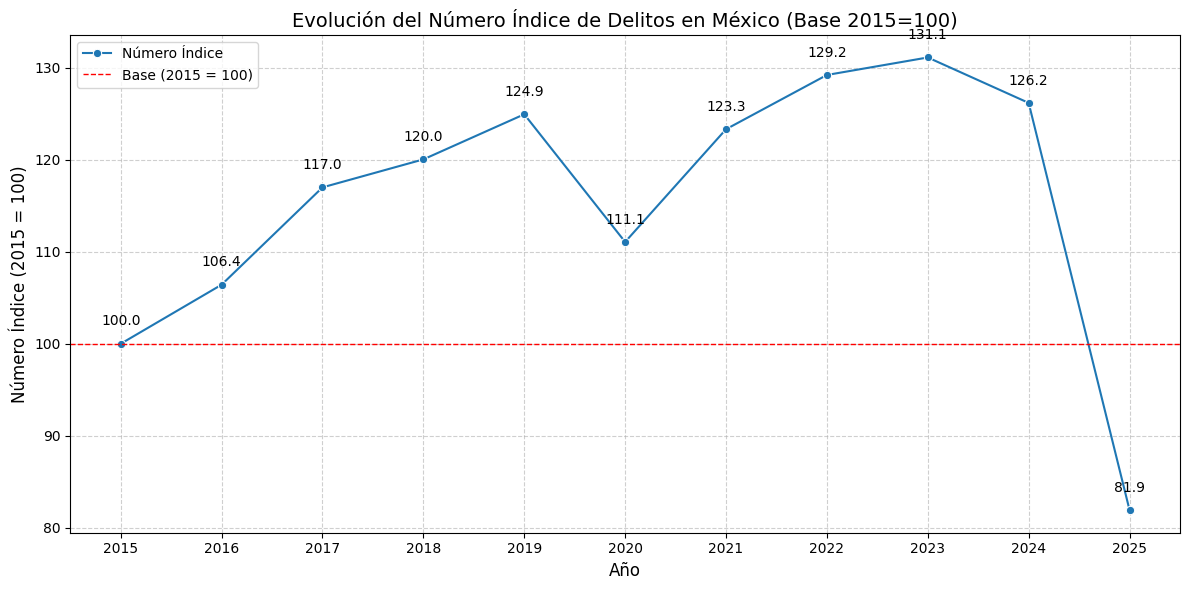

In [22]:
# Convertir 'Año' a string si no lo está, para que Seaborn lo trate como categorías discretas
df_nacional['Año'] = df_nacional['Año'].astype(str)

# Crear el gráfico de líneas y puntos
plt.figure(figsize=(12, 6))

# Usamos un gráfico de líneas para mostrar la evolución del índice
sns.lineplot(x='Año', y='Numero_Indice', data=df_nacional, marker='o', color='#1f77b4', label='Número Índice')


# Añadir etiquetas de texto a cada punto (valor del índice)
for i in range(len(df_nacional)):
    plt.text(
        x=df_nacional['Año'].iloc[i],
        y=df_nacional['Numero_Indice'].iloc[i] + 2, # +2 para que el texto esté ligeramente arriba del punto
        s=f"{df_nacional['Numero_Indice'].iloc[i]:.1f}",
        ha='center',
        fontsize=10
    )

# Personalizar el gráfico
plt.title(f'Evolución del Número Índice de Delitos en México (Base {año_base}=100)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número Índice (2015 = 100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(100, color='red', linestyle='--', linewidth=1, label='Base (2015 = 100)') # Línea de referencia en 100
plt.legend()
plt.tight_layout()
plt.show()

# **Rangos por edad**

In [23]:
df_victimas = pd.read_csv(f'{ruta_fuentes}/IDVFC_NM_ago25.csv', encoding='latin1')
df_victimas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80960 entries, 0 to 80959
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     80960 non-null  int64  
 1   Clave_Ent               80960 non-null  int64  
 2   Entidad                 80960 non-null  object 
 3   Bien jurídico afectado  80960 non-null  object 
 4   Tipo de delito          80960 non-null  object 
 5   Subtipo de delito       80960 non-null  object 
 6   Modalidad               80960 non-null  object 
 7   Sexo                    80960 non-null  object 
 8   Rango de edad           80960 non-null  object 
 9   Enero                   80960 non-null  int64  
 10  Febrero                 80960 non-null  int64  
 11  Marzo                   80960 non-null  int64  
 12  Abril                   80960 non-null  int64  
 13  Mayo                    80960 non-null  int64  
 14  Junio                   80960 non-null

DataFrame listo para graficar:
            Rango de edad  Número de Víctimas
0  Menores de edad (0-17)               23232
1      Adultos (18 y más)               23232
2         No especificado               23232
3         No identificado               11264


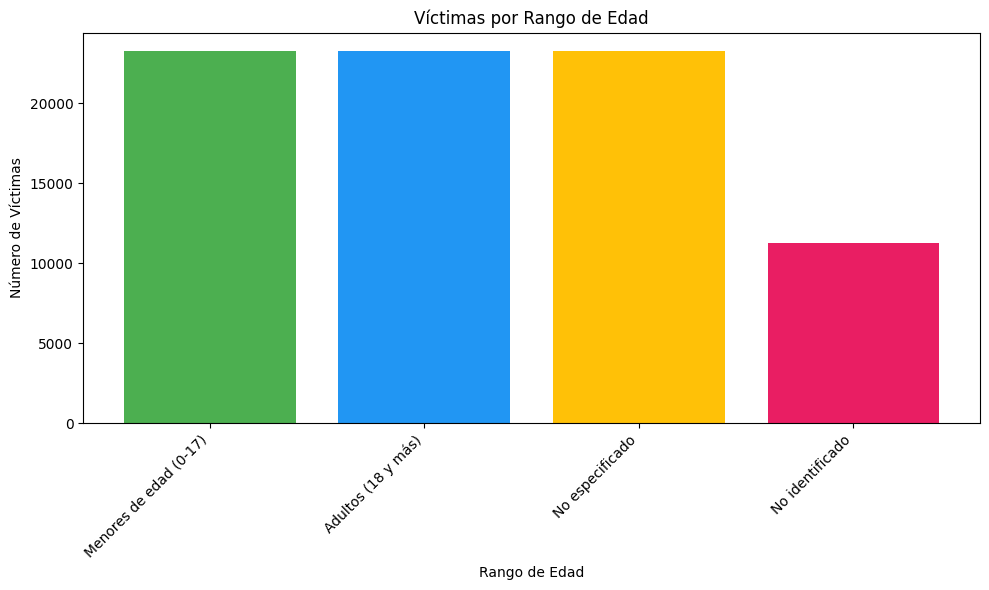

In [24]:
# 1. Contar la frecuencia de cada valor en la columna 'Rango de edad'
# Esto crea una Serie de pandas con los rangos como índice y el conteo como valor.
conteo_rangos = df_victimas['Rango de edad'].value_counts()

# 2. Convertir la Serie resultante en un nuevo DataFrame (opcional, pero útil)
df_rangos_para_grafica = conteo_rangos.reset_index()

# 3. Renombrar las columnas para que sean más descriptivas
df_rangos_para_grafica.columns = ['Rango de edad', 'Número de Víctimas']

print("DataFrame listo para graficar:")
print(df_rangos_para_grafica)

# Opcional: Ejemplo de cómo graficar los resultados con un gráfico de barras:
colores = ['#4CAF50', '#2196F3', '#FFC107', '#E91E63']

plt.figure(figsize=(10, 6))
plt.bar(df_rangos_para_grafica['Rango de edad'], df_rangos_para_grafica['Número de Víctimas'], color = colores)
plt.title('Víctimas por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Número de Víctimas')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor lectura
plt.tight_layout()
plt.show()

In [25]:
conteo_rangos = df_victimas['Rango de edad'].value_counts()
print(conteo_rangos)

Rango de edad
Menores de edad (0-17)    23232
Adultos (18 y más)        23232
No especificado           23232
No identificado           11264
Name: count, dtype: int64


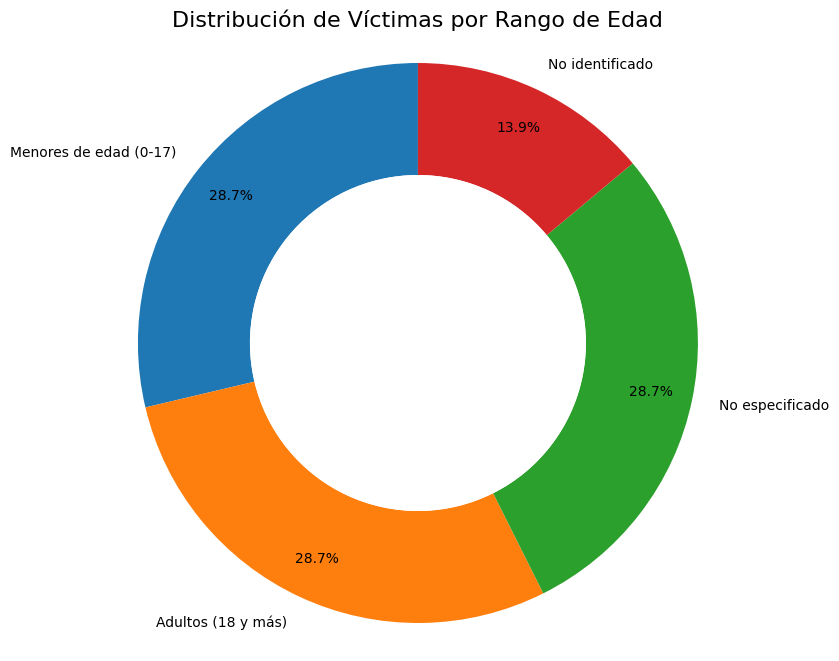

In [26]:
#Reprentación en gráfica de pastel


# --- Código para generar el diagrama de pastel ---

plt.figure(figsize=(10, 8)) # Ajusta el tamaño de la figura para una mejor visualización

# Crear el diagrama de pastel
plt.pie(
    df_rangos_para_grafica['Número de Víctimas'],  # Los tamaños de las "rebanadas"
    labels=df_rangos_para_grafica['Rango de edad'], # Las etiquetas para cada rebanada
    autopct='%1.1f%%',                             # Muestra el porcentaje en cada rebanada con un decimal
    startangle=90,                                 # Inicia el primer segmento en la parte superior (opcional)
    pctdistance=0.85,                              # Distancia de los porcentajes desde el centro
    wedgeprops=dict(width=0.4)                     # Crea un "donut chart" (opcional, puedes quitarlo para un pastel completo)
)

# Añadir un círculo central para convertirlo en un gráfico de "donut" (si wedgeprops está activado)
center_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Distribución de Víctimas por Rango de Edad', fontsize=16) # Título de la gráfica
plt.axis('equal') # Asegura que el diagrama de pastel sea un círculo.

plt.show()

# Conclusiones
- Con este análisis podemos identificar los delitos más frecuentes son robo, homicidio, lesiones, secuestro y feminicidio.
- Los estados con mayor incidencia delictiva son las ciudades más grandes del país y en especial resalta la zona metropolitana del Estado de México.
Esto nos muestra donde hay que invertir más recurso, vigilancia, efectivos como policia en los tres ordenes de gobierno además de reforzar los medios de vigilancia remota como lo son los C4.
-Así como hacer análisis de este tipo para monitoriar los avances y ajustar los parametros a implementar para obtener mejores resultados en cuanto seguridad pública.